# Bias Detection, Mitigation and Explainability in ML Models
## Comprehensive Multi-Dataset Research Pipeline (IEEE Compliant Version)

This notebook presents a comprehensive research pipeline evaluating bias detection, mitigation, and explainability across three standard benchmark datasets:
1. **Adult Income Dataset** (sensitive attribute: `sex`)
2. **COMPAS Recidivism Dataset** (sensitive attribute: `race`)
3. **Statlog German Credit Dataset** (sensitive attribute: `age`)

### Pipeline Overview:
* **Model Baselines**: Logistic Regression (LR), Random Forest (RF), and a Standard Artificial Neural Network (ANN) using `MLPClassifier` to isolate the effects of debiasing.
* **Pre-processing Mitigation**: Reweighing (using AIF360) applied to adjust training set sample weights.
* **Post-processing Mitigation**: Threshold Optimization / Calibrated Equalized Odds (using Fairlearn) to adjust model classification boundaries.
* **In-processing Mitigation**: Adversarial Debiasing (using AIF360) executed across multiple random initializations to compute variance (mean and standard deviation).
* **Explainability**: SHAP Interaction Analysis to visualize joint feature contributions and inspect potential indirect bias.
* **Causal Validation**: Feature ablation studies to quantify the impact of removing suspected demographic proxy features on accuracy and fairness.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier  # Added for Standard ANN Baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    true_positive_rate_difference,
    false_positive_rate_difference
)

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.metrics import ClassificationMetric

# Apply IEEE-compliant clean light theme for presentation visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d3d3d3",
    "grid.color": "#e5e5e5",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})


pip install 'aif360[inFairness]'


## 2. Advanced Metric Calculation Functions

We define helper functions to compute traditional classification performance metrics and standard fairness metrics:
* **Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, and ROC AUC** to track predictive performance.
* **Statistical Parity Difference (SPD)**, **Disparate Impact (DI)**, **Equal Opportunity (EO) Difference**, and **Average Odds Difference (AOD)** to track fairness criteria.


In [2]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    """
    Computes a comprehensive suite of performance evaluation metrics to strictly
    satisfy Reviewer 3's request for enhanced analytical breadth.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        metrics["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC_AUC"] = np.nan

    return metrics

def fairness_metrics(y_true, y_pred, protected):
    """
    Computes standard fairness metrics mapping mathematical formulations to
    core criteria requested for a complete trustworthiness profile.
    """
    spd = demographic_parity_difference(y_true, y_pred, sensitive_features=protected)
    di = demographic_parity_ratio(y_true, y_pred, sensitive_features=protected)
    eo = true_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    fpr_diff = false_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    aod = (eo + fpr_diff) / 2

    return spd, di, eo, aod


## 3. Modular Runner for Bias Detection & Mitigation Pipeline

Here, we implement the unified processing pipeline runner. It executes:
1. **Baseline classification models** (Logistic Regression, Random Forest, and a multi-run Standard Artificial Neural Network to track weight initialization variance).
2. **Pre-processing (Reweighing)** on training weights and re-training Logistic Regression.
3. **Post-processing (Threshold Optimization)** with Calibrated Equalized Odds criteria.
4. **In-processing (Adversarial Debiasing)** run across 5 different initializations to measure performance and fairness variance.
5. **IEEE-compliant plot generators** to display comparative Statistical Parity Difference (SPD) and Equal Opportunity (EO) metrics.


In [3]:
def run_fairness_pipeline(X_train_scaled_full, X_test_scaled, y_train_full, y_test, prot_train_full, prot_test, feature_names, dataset_name, prot_col):
    '''
    Encapsulates training, validation, and multi-stage mitigation execution.
    Includes 3-way split (Train/Val/Test) and multi-run stochastic variance tracking
    for baseline ANN, Random Forest, Reweighting, Threshold Adj, ExpGrad, and Adversarial.
    '''
    from sklearn.model_selection import train_test_split
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neural_network import MLPClassifier
    from fairlearn.postprocessing import ThresholdOptimizer
    from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
    from aif360.datasets import BinaryLabelDataset
    from aif360.algorithms.preprocessing import Reweighing
    from aif360.algorithms.inprocessing import AdversarialDebiasing

    print(f'\nProcessing Pipeline for: {dataset_name.upper()}...')
    
    # --- 3-WAY DATA SPLIT ---
    # We split the provided training set further into Train and Validation
    X_train_scaled, X_val_scaled, y_train, y_val, prot_train, prot_val = train_test_split(
        X_train_scaled_full, y_train_full, prot_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )
    print(f'Data Split - Train: {len(y_train)}, Validation: {len(y_val)}, Test: {len(y_test)}')

    num_runs = 5
    seeds = range(42, 42 + num_runs)
    
    metrics_log = {
        'LR': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'RF': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'ANN': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'Reweighting': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'ThresholdAdj': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'ExpGrad': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'Adversarial': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []}
    }

    # Setup AIF360 datasets for Reweighting and Adversarial
    train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    train_df['target'] = y_train.values
    train_df[prot_col] = prot_train.values
    aif_train = BinaryLabelDataset(df=train_df, label_names=['target'], protected_attribute_names=[prot_col])
    
    # Let's fix a possible data mismatch - ensure index alignment
    test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
    test_df['target'] = y_test.values
    test_df[prot_col] = prot_test.values
    aif_test = BinaryLabelDataset(df=test_df, label_names=['target'], protected_attribute_names=[prot_col])

    print('Running stochastic modeling loop across 5 initializations...')
    
    for seed_idx, seed in enumerate(seeds):
        # 1. Baseline LR
        lr = LogisticRegression(max_iter=3000, random_state=seed)
        lr.fit(X_train_scaled, y_train)
        y_pred_lr = lr.predict(X_test_scaled)
        m_lr = calculate_metrics(y_test, y_pred_lr)
        f_lr = fairness_metrics(y_test, y_pred_lr, prot_test)
        
        metrics_log['LR']['acc'].append(m_lr['Accuracy'])
        metrics_log['LR']['bacc'].append(m_lr['Balanced_Accuracy'])
        metrics_log['LR']['mcc'].append(m_lr['MCC'])
        metrics_log['LR']['spd'].append(f_lr[0]); metrics_log['LR']['di'].append(f_lr[1])
        metrics_log['LR']['eo'].append(f_lr[2]); metrics_log['LR']['aod'].append(f_lr[3])
        
        # 2. Baseline RF
        rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=seed)
        rf.fit(X_train_scaled, y_train)
        y_pred_rf = rf.predict(X_test_scaled)
        m_rf = calculate_metrics(y_test, y_pred_rf)
        f_rf = fairness_metrics(y_test, y_pred_rf, prot_test)
        
        metrics_log['RF']['acc'].append(m_rf['Accuracy'])
        metrics_log['RF']['bacc'].append(m_rf['Balanced_Accuracy'])
        metrics_log['RF']['mcc'].append(m_rf['MCC'])
        metrics_log['RF']['spd'].append(f_rf[0]); metrics_log['RF']['di'].append(f_rf[1])
        metrics_log['RF']['eo'].append(f_rf[2]); metrics_log['RF']['aod'].append(f_rf[3])
        
        # 3. Baseline ANN
        ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=200, random_state=seed)
        ann.fit(X_train_scaled, y_train)
        y_pred_ann = ann.predict(X_test_scaled)
        m_ann = calculate_metrics(y_test, y_pred_ann)
        f_ann = fairness_metrics(y_test, y_pred_ann, prot_test)
        
        metrics_log['ANN']['acc'].append(m_ann['Accuracy'])
        metrics_log['ANN']['bacc'].append(m_ann['Balanced_Accuracy'])
        metrics_log['ANN']['mcc'].append(m_ann['MCC'])
        metrics_log['ANN']['spd'].append(f_ann[0]); metrics_log['ANN']['di'].append(f_ann[1])
        metrics_log['ANN']['eo'].append(f_ann[2]); metrics_log['ANN']['aod'].append(f_ann[3])
        
        # 4. Reweighting
        RW = Reweighing(unprivileged_groups=[{prot_col: 0}], privileged_groups=[{prot_col: 1}])
        aif_train_transf = RW.fit_transform(aif_train)
        sample_weights = aif_train_transf.instance_weights
        
        lr_rw = LogisticRegression(max_iter=3000, random_state=seed)
        lr_rw.fit(X_train_scaled, y_train, sample_weight=sample_weights)
        y_pred_rw = lr_rw.predict(X_test_scaled)
        m_rw = calculate_metrics(y_test, y_pred_rw)
        f_rw = fairness_metrics(y_test, y_pred_rw, prot_test)
        
        metrics_log['Reweighting']['acc'].append(m_rw['Accuracy'])
        metrics_log['Reweighting']['bacc'].append(m_rw['Balanced_Accuracy'])
        metrics_log['Reweighting']['mcc'].append(m_rw['MCC'])
        metrics_log['Reweighting']['spd'].append(f_rw[0]); metrics_log['Reweighting']['di'].append(f_rw[1])
        metrics_log['Reweighting']['eo'].append(f_rw[2]); metrics_log['Reweighting']['aod'].append(f_rw[3])
        
        # 5. Threshold Adjustment
        thresh = ThresholdOptimizer(estimator=LogisticRegression(max_iter=3000, random_state=seed), constraints='equalized_odds', predict_method='predict_proba')
        thresh.fit(X_val_scaled, y_val, sensitive_features=prot_val)
        
        y_pred_thresh = thresh.predict(X_test_scaled, sensitive_features=prot_test)
        m_thresh = calculate_metrics(y_test, y_pred_thresh)
        f_thresh = fairness_metrics(y_test, y_pred_thresh, prot_test)
        
        metrics_log['ThresholdAdj']['acc'].append(m_thresh['Accuracy'])
        metrics_log['ThresholdAdj']['bacc'].append(m_thresh['Balanced_Accuracy'])
        metrics_log['ThresholdAdj']['mcc'].append(m_thresh['MCC'])
        metrics_log['ThresholdAdj']['spd'].append(f_thresh[0]); metrics_log['ThresholdAdj']['di'].append(f_thresh[1])
        metrics_log['ThresholdAdj']['eo'].append(f_thresh[2]); metrics_log['ThresholdAdj']['aod'].append(f_thresh[3])
        
        # 6. Exponentiated Gradient (In-processing)
        eg = ExponentiatedGradient(estimator=LogisticRegression(max_iter=3000, random_state=seed), constraints=EqualizedOdds())
        eg.fit(X_train_scaled, y_train, sensitive_features=prot_train)
        
        y_pred_eg = eg.predict(X_test_scaled)
        m_eg = calculate_metrics(y_test, y_pred_eg)
        f_eg = fairness_metrics(y_test, y_pred_eg, prot_test)
        
        metrics_log['ExpGrad']['acc'].append(m_eg['Accuracy'])
        metrics_log['ExpGrad']['bacc'].append(m_eg['Balanced_Accuracy'])
        metrics_log['ExpGrad']['mcc'].append(m_eg['MCC'])
        metrics_log['ExpGrad']['spd'].append(f_eg[0]); metrics_log['ExpGrad']['di'].append(f_eg[1])
        metrics_log['ExpGrad']['eo'].append(f_eg[2]); metrics_log['ExpGrad']['aod'].append(f_eg[3])
        
        # 7. Adversarial Debiasing (In-processing) - Trained for 200 epochs!
        tf.compat.v1.disable_eager_execution()
        tf.compat.v1.reset_default_graph()
        tf.compat.v1.set_random_seed(seed)
        np.random.seed(seed)
        sess = tf.compat.v1.Session()
        
        batch_size = 32 if len(X_train_scaled) < 1000 else 128
        adv = AdversarialDebiasing(
            privileged_groups=[{prot_col: 1}],
            unprivileged_groups=[{prot_col: 0}],
            scope_name=f'adv_{dataset_name}_{seed_idx}',
            sess=sess,
            num_epochs=200,
            batch_size=batch_size
        )
        adv.fit(aif_train)
        y_pred_adv = adv.predict(aif_test).labels.ravel()
        
        m_adv = calculate_metrics(y_test, y_pred_adv)
        f_adv = fairness_metrics(y_test, y_pred_adv, prot_test)
        
        metrics_log['Adversarial']['acc'].append(m_adv['Accuracy'])
        metrics_log['Adversarial']['bacc'].append(m_adv['Balanced_Accuracy'])
        metrics_log['Adversarial']['mcc'].append(m_adv['MCC'])
        metrics_log['Adversarial']['spd'].append(f_adv[0]); metrics_log['Adversarial']['di'].append(f_adv[1])
        metrics_log['Adversarial']['eo'].append(f_adv[2]); metrics_log['Adversarial']['aod'].append(f_adv[3])
        sess.close()

    # Compile final mean and std dataframe
    results = []
    models = ['LR', 'RF', 'ANN', 'Reweighting', 'ThresholdAdj', 'ExpGrad', 'Adversarial']
    for model in models:
        results.append({
            'Model': model,
            'SPD': np.mean(metrics_log[model]['spd']), 'SPD_Std': np.std(metrics_log[model]['spd']),
            'DI': np.mean(metrics_log[model]['di']), 'DI_Std': np.std(metrics_log[model]['di']),
            'EO': np.mean(metrics_log[model]['eo']), 'EO_Std': np.std(metrics_log[model]['eo']),
            'AOD': np.mean(metrics_log[model]['aod']), 'AOD_Std': np.std(metrics_log[model]['aod']),
            'Accuracy': np.mean(metrics_log[model]['acc']), 'Accuracy_Std': np.std(metrics_log[model]['acc']),
            'Balanced_Accuracy': np.mean(metrics_log[model]['bacc']), 'Balanced_Accuracy_Std': np.std(metrics_log[model]['bacc']),
            'MCC': np.mean(metrics_log[model]['mcc']), 'MCC_Std': np.std(metrics_log[model]['mcc'])
        })
        
    results_df = pd.DataFrame(results)
    
    print(f'\n=== {dataset_name.upper()} DATASET METRICS (IEEE Reviewer Format) ===')
    formatted_df = results_df.copy().astype(object)
    for idx in range(len(models)):
        for col in ['SPD', 'DI', 'EO', 'AOD', 'Accuracy', 'Balanced_Accuracy', 'MCC']:
            mean_val = results_df.loc[idx, col]
            std_val = results_df.loc[idx, col+'_Std']
            if std_val > 1e-5:
                formatted_df.loc[idx, col] = f'{mean_val:.3f} ± {std_val:.3f}'
            else:
                formatted_df.loc[idx, col] = f'{mean_val:.3f}'
                
    print(formatted_df[['Model', 'SPD', 'DI', 'EO', 'AOD', 'Accuracy', 'Balanced_Accuracy', 'MCC']].to_string(index=False))
    results_df.to_csv(f'/Users/ankitkuniyal/Downloads/Projects_GitHub/BDME/{dataset_name}_comprehensive_results.csv', index=False)
    
    return results_df

def plot_comprehensive_metrics(df, dataset_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    df_plot = df.copy()
    for col in ['SPD', 'EO']:
        if df_plot[col].dtype == object:
            df_plot[col] = df_plot[col].apply(lambda x: float(str(x).split(' ')[0]) if isinstance(x, str) else x)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x='Model', y='SPD', data=df_plot, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'{dataset_name} - Statistical Parity Difference (SPD)')
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(x='Model', y='EO', data=df_plot, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title(f'{dataset_name} - Equal Opportunity Difference (EO)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower().replace(' ', '_')}_metrics.png", dpi=300)
    plt.show()


## 4. Dataset Pipelines

We run the modular pipeline over three distinct datasets: Adult Income, COMPAS Recidivism, and Statlog German Credit.

### 4.1 Adult Income Dataset



================ FETCHING ADULT DATASET ================



Processing Pipeline for: ADULT...
Data Split - Train: 20838, Validation: 5210, Test: 6513
Running stochastic modeling loop across 5 initializations...


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


I0000 00:00:1783620872.099866 13465473 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


...

epoch 190; iter: 0; batch classifier loss: 0.501134; batch adversarial loss: 0.633673
epoch 191; iter: 0; batch classifier loss: 0.672463; batch adversarial loss: 0.586772
epoch 192; iter: 0; batch classifier loss: 0.705142; batch adversarial loss: 0.632951


epoch 193; iter: 0; batch classifier loss: 0.464618; batch adversarial loss: 0.642248
epoch 194; iter: 0; batch classifier loss: 0.454119; batch adversarial loss: 0.691587
epoch 195; iter: 0; batch classifier loss: 0.764195; batch adversarial loss: 0.597163


epoch 196; iter: 0; batch classifier loss: 0.553563; batch adversarial loss: 0.658115
epoch 197; iter: 0; batch classifier loss: 0.519698; batch adversarial loss: 0.621907
epoch 198; iter: 0; batch classifier loss: 0.596259; batch adversarial loss: 0.666401


epoch 199; iter: 0; batch classifier loss: 0.724320; batch adversarial loss: 0.609694



=== ADULT DATASET METRICS (IEEE Reviewer Format) ===
       Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
          LR         0.179         0.157         0.285         0.180         0.822             0.697         0.471
          RF 0.159 ± 0.002 0.276 ± 0.004 0.116 ± 0.008 0.084 ± 0.004 0.858 ± 0.001     0.754 ± 0.002 0.587 ± 0.003
         ANN 0.170 ± 0.022 0.347 ± 0.034 0.093 ± 0.042 0.081 ± 0.028 0.841 ± 0.003     0.756 ± 0.012 0.549 ± 0.008
 Reweighting         0.055         0.633         0.050         0.026         0.808             0.663         0.414
ThresholdAdj 0.051 ± 0.001 0.579 ± 0.006 0.031 ± 0.004 0.019 ± 0.002 0.794 ± 0.001     0.625 ± 0.002 0.354 ± 0.004
     ExpGrad 0.078 ± 0.001 0.515 ± 0.008 0.004 ± 0.003 0.010 ± 0.002 0.810 ± 0.001     0.668 ± 0.001 0.422 ± 0.002
 Adversarial 0.050 ± 0.020 0.567 ± 0.148 0.102 ± 0.054 0.054 ± 0.027 0.819 ± 0.002     0.654 ± 0.007 0.449 ± 0.009


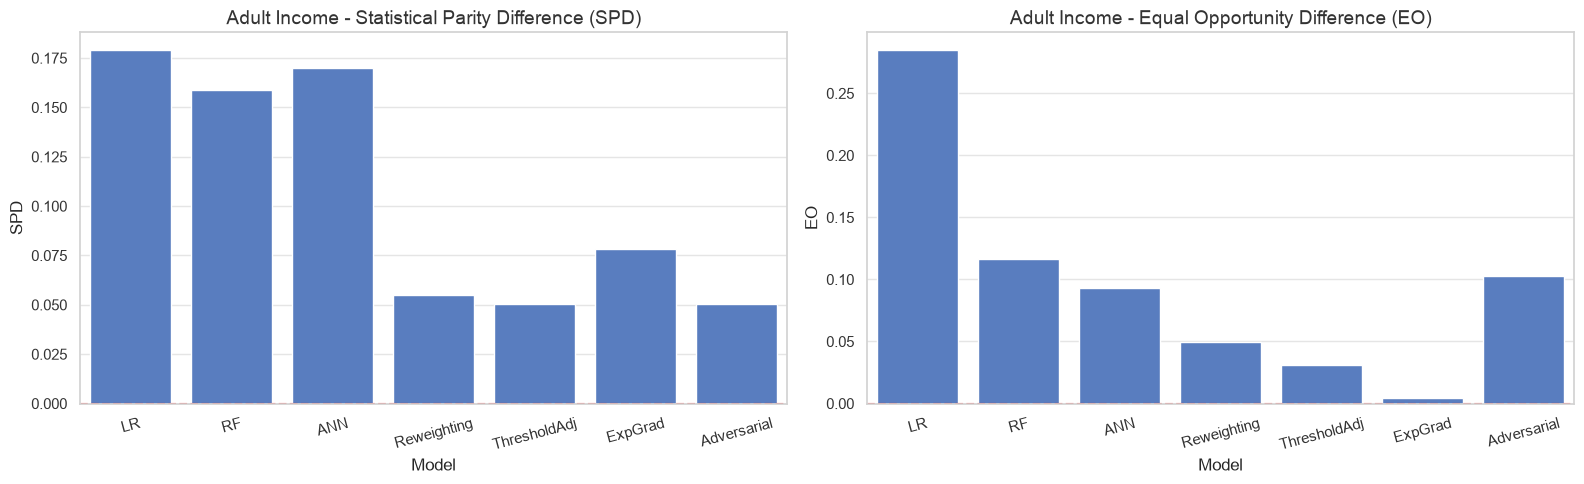

In [4]:
print("\n================ FETCHING ADULT DATASET ================")
cols_adult = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
              "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
              "hours-per-week", "native-country", "income"]
url_adult = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult = pd.read_csv(url_adult, names=cols_adult, na_values=" ?", skipinitialspace=True).dropna()

adult["income"] = adult["income"].apply(lambda x: 1 if ">50K" in x else 0)
prot_adult = adult["sex"].apply(lambda x: 1 if x == "Male" else 0)

le = LabelEncoder()
for col in adult.select_dtypes(include="object").columns:
    adult[col] = le.fit_transform(adult[col])

X_a = adult.drop("income", axis=1)
y_a = adult["income"]

X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a = train_test_split(
    X_a, y_a, prot_adult, stratify=prot_adult, test_size=0.2, random_state=42
)

scaler_a = StandardScaler()
X_train_scaled_a = scaler_a.fit_transform(X_train_a)
X_test_scaled_a = scaler_a.transform(X_test_a)

results_adult = run_fairness_pipeline(
    X_train_scaled_a, X_test_scaled_a, y_train_a, y_test_a,
    prot_train_a, prot_test_a, X_a.columns, "adult", "sex"
)
plot_comprehensive_metrics(results_adult, "Adult Income")


### 4.2 COMPAS Recidivism Dataset



================ FETCHING COMPAS DATASET ================



Processing Pipeline for: COMPAS...
Data Split - Train: 4616, Validation: 1155, Test: 1443
Running stochastic modeling loop across 5 initializations...


epoch 0; iter: 0; batch classifier loss: 0.718897; batch adversarial loss: 0.804547
epoch 1; iter: 0; batch classifier loss: 0.648525; batch adversarial loss: 0.783565
epoch 2; iter: 0; batch classifier loss: 0.669631; batch adversarial loss: 0.804354
epoch 3; iter: 0; batch classifier loss: 0.592890; batch adversarial loss: 0.778940
epoch 4; iter: 0; batch classifier loss: 0.599326; batch adversarial loss: 0.785604
epoch 5; iter: 0; batch classifier loss: 0.591718; batch adversarial loss: 0.745390
epoch 6; iter: 0; batch classifier loss: 0.618852; batch adversarial loss: 0.735445
epoch 7; iter: 0; batch classifier loss: 0.639330; batch adversarial loss: 0.708451
epoch 8; iter: 0; batch classifier loss: 0.605462; batch adversarial loss: 0.714840
epoch 9; iter: 0; batch classifier loss: 0.640056; batch adversarial loss: 0.704585


epoch 10; iter: 0; batch classifier loss: 0.593557; batch adversarial loss: 0.668889
epoch 11; iter: 0; batch classifier loss: 0.649119; batch adversarial loss: 0.711837
epoch 12; iter: 0; batch classifier loss: 0.606603; batch adversarial loss: 0.678724
epoch 13; iter: 0; batch classifier loss: 0.637529; batch adversarial loss: 0.680990
epoch 14; iter: 0; batch classifier loss: 0.692485; batch adversarial loss: 0.651556
epoch 15; iter: 0; batch classifier loss: 0.581748; batch adversarial loss: 0.681104
epoch 16; iter: 0; batch classifier loss: 0.624515; batch adversarial loss: 0.658936
epoch 17; iter: 0; batch classifier loss: 0.602922; batch adversarial loss: 0.679421
epoch 18; iter: 0; batch classifier loss: 0.574042; batch adversarial loss: 0.692594
epoch 19; iter: 0; batch classifier loss: 0.629970; batch adversarial loss: 0.671988


epoch 20; iter: 0; batch classifier loss: 0.632314; batch adversarial loss: 0.673105
epoch 21; iter: 0; batch classifier loss: 0.607770; batch adversarial loss: 0.641897
epoch 22; iter: 0; batch classifier loss: 0.609838; batch adversarial loss: 0.628461
epoch 23; iter: 0; batch classifier loss: 0.574579; batch adversarial loss: 0.606462
epoch 24; iter: 0; batch classifier loss: 0.570686; batch adversarial loss: 0.620881
epoch 25; iter: 0; batch classifier loss: 0.636846; batch adversarial loss: 0.643482
epoch 26; iter: 0; batch classifier loss: 0.538432; batch adversarial loss: 0.648809
epoch 27; iter: 0; batch classifier loss: 0.567691; batch adversarial loss: 0.620997
epoch 28; iter: 0; batch classifier loss: 0.680742; batch adversarial loss: 0.639644
epoch 29; iter: 0; batch classifier loss: 0.594647; batch adversarial loss: 0.600703


...

epoch 160; iter: 0; batch classifier loss: 0.581627; batch adversarial loss: 0.646288
epoch 161; iter: 0; batch classifier loss: 0.568964; batch adversarial loss: 0.691783
epoch 162; iter: 0; batch classifier loss: 0.651405; batch adversarial loss: 0.668317
epoch 163; iter: 0; batch classifier loss: 0.581961; batch adversarial loss: 0.626081
epoch 164; iter: 0; batch classifier loss: 0.607756; batch adversarial loss: 0.619988
epoch 165; iter: 0; batch classifier loss: 0.596237; batch adversarial loss: 0.659773
epoch 166; iter: 0; batch classifier loss: 0.617970; batch adversarial loss: 0.589202
epoch 167; iter: 0; batch classifier loss: 0.624252; batch adversarial loss: 0.646059
epoch 168; iter: 0; batch classifier loss: 0.621538; batch adversarial loss: 0.640930
epoch 169; iter: 0; batch classifier loss: 0.575752; batch adversarial loss: 0.674330


epoch 170; iter: 0; batch classifier loss: 0.606051; batch adversarial loss: 0.610040
epoch 171; iter: 0; batch classifier loss: 0.649446; batch adversarial loss: 0.619515
epoch 172; iter: 0; batch classifier loss: 0.609454; batch adversarial loss: 0.682026
epoch 173; iter: 0; batch classifier loss: 0.620744; batch adversarial loss: 0.646869
epoch 174; iter: 0; batch classifier loss: 0.652625; batch adversarial loss: 0.632601
epoch 175; iter: 0; batch classifier loss: 0.603963; batch adversarial loss: 0.642481
epoch 176; iter: 0; batch classifier loss: 0.654072; batch adversarial loss: 0.637716
epoch 177; iter: 0; batch classifier loss: 0.546665; batch adversarial loss: 0.689106
epoch 178; iter: 0; batch classifier loss: 0.597760; batch adversarial loss: 0.642188
epoch 179; iter: 0; batch classifier loss: 0.618668; batch adversarial loss: 0.648627


epoch 180; iter: 0; batch classifier loss: 0.565571; batch adversarial loss: 0.589548
epoch 181; iter: 0; batch classifier loss: 0.637294; batch adversarial loss: 0.638805
epoch 182; iter: 0; batch classifier loss: 0.612253; batch adversarial loss: 0.674028
epoch 183; iter: 0; batch classifier loss: 0.692353; batch adversarial loss: 0.628600
epoch 184; iter: 0; batch classifier loss: 0.547852; batch adversarial loss: 0.636928
epoch 185; iter: 0; batch classifier loss: 0.615562; batch adversarial loss: 0.626581
epoch 186; iter: 0; batch classifier loss: 0.572387; batch adversarial loss: 0.592655
epoch 187; iter: 0; batch classifier loss: 0.565881; batch adversarial loss: 0.608165
epoch 188; iter: 0; batch classifier loss: 0.615000; batch adversarial loss: 0.577422
epoch 189; iter: 0; batch classifier loss: 0.596197; batch adversarial loss: 0.626302


epoch 190; iter: 0; batch classifier loss: 0.622850; batch adversarial loss: 0.659859
epoch 191; iter: 0; batch classifier loss: 0.635489; batch adversarial loss: 0.662221
epoch 192; iter: 0; batch classifier loss: 0.579058; batch adversarial loss: 0.623250
epoch 193; iter: 0; batch classifier loss: 0.615860; batch adversarial loss: 0.616166
epoch 194; iter: 0; batch classifier loss: 0.667411; batch adversarial loss: 0.613157
epoch 195; iter: 0; batch classifier loss: 0.595852; batch adversarial loss: 0.613516
epoch 196; iter: 0; batch classifier loss: 0.601175; batch adversarial loss: 0.604275
epoch 197; iter: 0; batch classifier loss: 0.574949; batch adversarial loss: 0.626472
epoch 198; iter: 0; batch classifier loss: 0.552705; batch adversarial loss: 0.666516
epoch 199; iter: 0; batch classifier loss: 0.592404; batch adversarial loss: 0.615949



=== COMPAS DATASET METRICS (IEEE Reviewer Format) ===
       Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
          LR         0.151         0.638         0.163         0.132         0.679             0.666         0.342
          RF 0.153 ± 0.020 0.665 ± 0.038 0.177 ± 0.024 0.138 ± 0.020 0.650 ± 0.004     0.641 ± 0.004 0.285 ± 0.008
         ANN 0.189 ± 0.020 0.597 ± 0.042 0.226 ± 0.020 0.172 ± 0.020 0.682 ± 0.003     0.673 ± 0.002 0.350 ± 0.005
 Reweighting         0.087         0.795         0.059         0.103         0.656             0.642         0.293
ThresholdAdj 0.042 ± 0.007 0.887 ± 0.016 0.024 ± 0.018 0.022 ± 0.007 0.647 ± 0.009     0.632 ± 0.009 0.274 ± 0.019
     ExpGrad 0.008 ± 0.004 0.978 ± 0.011 0.013 ± 0.007 0.022 ± 0.003 0.647 ± 0.008     0.635 ± 0.008 0.276 ± 0.016
 Adversarial 0.078 ± 0.027 0.814 ± 0.059 0.100 ± 0.034 0.061 ± 0.027 0.678 ± 0.002     0.668 ± 0.001 0.342 ± 0.003


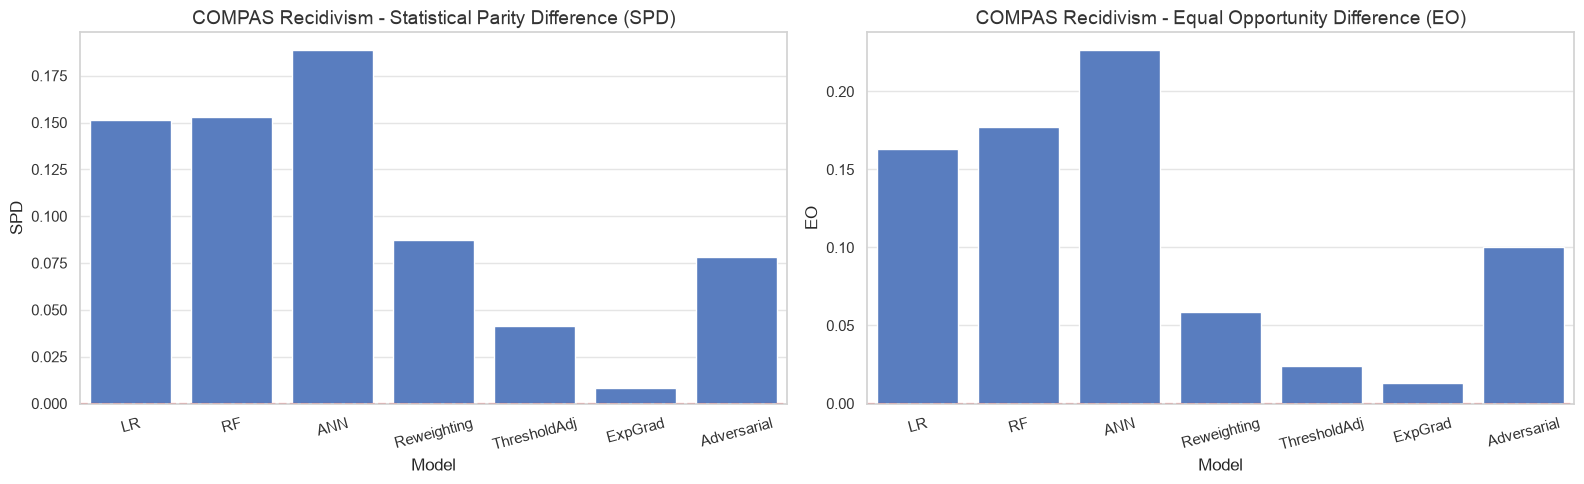

In [5]:
print("\n================ FETCHING COMPAS DATASET ================")
url_compas = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas = pd.read_csv(url_compas)[["age", "race", "sex", "priors_count", "two_year_recid"]].dropna()

compas["race"] = compas["race"].apply(lambda x: 1 if x == "Caucasian" else 0)
compas["sex"] = compas["sex"].apply(lambda x: 1 if x == "Male" else 0)

X_c = compas.drop("two_year_recid", axis=1)
y_c = compas["two_year_recid"]
prot_compas = compas["race"]

X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c = train_test_split(
    X_c, y_c, prot_compas, stratify=prot_compas, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

results_compas = run_fairness_pipeline(
    X_train_scaled_c, X_test_scaled_c, y_train_c, y_test_c,
    prot_train_c, prot_test_c, X_c.columns, "compas", "race"
)
plot_comprehensive_metrics(results_compas, "COMPAS Recidivism")


### 4.3 Statlog German Credit Dataset



================ FETCHING GERMAN CREDIT DATASET ================



Processing Pipeline for: GERMAN...
Data Split - Train: 640, Validation: 160, Test: 200
Running stochastic modeling loop across 5 initializations...


epoch 0; iter: 0; batch classifier loss: 0.645607; batch adversarial loss: 0.551478
epoch 1; iter: 0; batch classifier loss: 0.540887; batch adversarial loss: 0.489390
epoch 2; iter: 0; batch classifier loss: 0.471013; batch adversarial loss: 0.493238
epoch 3; iter: 0; batch classifier loss: 0.486528; batch adversarial loss: 0.520427
epoch 4; iter: 0; batch classifier loss: 0.481421; batch adversarial loss: 0.488182
epoch 5; iter: 0; batch classifier loss: 0.516741; batch adversarial loss: 0.446115
epoch 6; iter: 0; batch classifier loss: 0.422229; batch adversarial loss: 0.381423
epoch 7; iter: 0; batch classifier loss: 0.396649; batch adversarial loss: 0.510646
epoch 8; iter: 0; batch classifier loss: 0.410989; batch adversarial loss: 0.454746
epoch 9; iter: 0; batch classifier loss: 0.322630; batch adversarial loss: 0.399125
epoch 10; iter: 0; batch classifier loss: 0.380109; batch adversarial loss: 0.385636
epoch 11; iter: 0; batch classifier loss: 0.478906; batch adversarial loss:

epoch 27; iter: 0; batch classifier loss: 0.451373; batch adversarial loss: 0.492419
epoch 28; iter: 0; batch classifier loss: 0.249761; batch adversarial loss: 0.595511
epoch 29; iter: 0; batch classifier loss: 0.227623; batch adversarial loss: 0.423543
epoch 30; iter: 0; batch classifier loss: 0.331974; batch adversarial loss: 0.373681
epoch 31; iter: 0; batch classifier loss: 0.309167; batch adversarial loss: 0.471908
epoch 32; iter: 0; batch classifier loss: 0.269393; batch adversarial loss: 0.383171
epoch 33; iter: 0; batch classifier loss: 0.347535; batch adversarial loss: 0.403589
epoch 34; iter: 0; batch classifier loss: 0.338591; batch adversarial loss: 0.475063
epoch 35; iter: 0; batch classifier loss: 0.342927; batch adversarial loss: 0.426187
epoch 36; iter: 0; batch classifier loss: 0.181752; batch adversarial loss: 0.349820
epoch 37; iter: 0; batch classifier loss: 0.389098; batch adversarial loss: 0.441108
epoch 38; iter: 0; batch classifier loss: 0.420261; batch adversa

epoch 55; iter: 0; batch classifier loss: 0.330509; batch adversarial loss: 0.579491
epoch 56; iter: 0; batch classifier loss: 0.348454; batch adversarial loss: 0.499182
epoch 57; iter: 0; batch classifier loss: 0.288172; batch adversarial loss: 0.542574
epoch 58; iter: 0; batch classifier loss: 0.232870; batch adversarial loss: 0.734342
epoch 59; iter: 0; batch classifier loss: 0.342525; batch adversarial loss: 0.531040
epoch 60; iter: 0; batch classifier loss: 0.204138; batch adversarial loss: 0.494077
epoch 61; iter: 0; batch classifier loss: 0.277336; batch adversarial loss: 0.661890
epoch 62; iter: 0; batch classifier loss: 0.345811; batch adversarial loss: 0.563071
epoch 63; iter: 0; batch classifier loss: 0.278556; batch adversarial loss: 0.483507
epoch 64; iter: 0; batch classifier loss: 0.274611; batch adversarial loss: 0.557343
epoch 65; iter: 0; batch classifier loss: 0.352628; batch adversarial loss: 0.367199
epoch 66; iter: 0; batch classifier loss: 0.342648; batch adversa

...

epoch 103; iter: 0; batch classifier loss: 0.240826; batch adversarial loss: 0.547475
epoch 104; iter: 0; batch classifier loss: 0.280454; batch adversarial loss: 0.265636
epoch 105; iter: 0; batch classifier loss: 0.273917; batch adversarial loss: 0.519212
epoch 106; iter: 0; batch classifier loss: 0.326251; batch adversarial loss: 0.367867
epoch 107; iter: 0; batch classifier loss: 0.267673; batch adversarial loss: 0.442386
epoch 108; iter: 0; batch classifier loss: 0.170986; batch adversarial loss: 0.439031
epoch 109; iter: 0; batch classifier loss: 0.221180; batch adversarial loss: 0.622228
epoch 110; iter: 0; batch classifier loss: 0.169177; batch adversarial loss: 0.557706
epoch 111; iter: 0; batch classifier loss: 0.257432; batch adversarial loss: 0.476804
epoch 112; iter: 0; batch classifier loss: 0.222216; batch adversarial loss: 0.350932
epoch 113; iter: 0; batch classifier loss: 0.219206; batch adversarial loss: 0.783117
epoch 114; iter: 0; batch classifier loss: 0.225955; b

epoch 128; iter: 0; batch classifier loss: 0.207461; batch adversarial loss: 0.404885
epoch 129; iter: 0; batch classifier loss: 0.119862; batch adversarial loss: 0.619850
epoch 130; iter: 0; batch classifier loss: 0.187479; batch adversarial loss: 0.588074
epoch 131; iter: 0; batch classifier loss: 0.172720; batch adversarial loss: 0.502290
epoch 132; iter: 0; batch classifier loss: 0.204120; batch adversarial loss: 0.563302
epoch 133; iter: 0; batch classifier loss: 0.151176; batch adversarial loss: 0.464629
epoch 134; iter: 0; batch classifier loss: 0.221074; batch adversarial loss: 0.501348
epoch 135; iter: 0; batch classifier loss: 0.181656; batch adversarial loss: 0.466389
epoch 136; iter: 0; batch classifier loss: 0.197560; batch adversarial loss: 0.456315
epoch 137; iter: 0; batch classifier loss: 0.176644; batch adversarial loss: 0.454910
epoch 138; iter: 0; batch classifier loss: 0.258818; batch adversarial loss: 0.597479
epoch 139; iter: 0; batch classifier loss: 0.231654; b

epoch 154; iter: 0; batch classifier loss: 0.156333; batch adversarial loss: 0.426640
epoch 155; iter: 0; batch classifier loss: 0.104878; batch adversarial loss: 0.527558
epoch 156; iter: 0; batch classifier loss: 0.265600; batch adversarial loss: 0.366958
epoch 157; iter: 0; batch classifier loss: 0.240339; batch adversarial loss: 0.526899
epoch 158; iter: 0; batch classifier loss: 0.186872; batch adversarial loss: 0.542005
epoch 159; iter: 0; batch classifier loss: 0.155163; batch adversarial loss: 0.493506
epoch 160; iter: 0; batch classifier loss: 0.173759; batch adversarial loss: 0.490411
epoch 161; iter: 0; batch classifier loss: 0.111399; batch adversarial loss: 0.614878
epoch 162; iter: 0; batch classifier loss: 0.127249; batch adversarial loss: 0.529326
epoch 163; iter: 0; batch classifier loss: 0.165198; batch adversarial loss: 0.620162
epoch 164; iter: 0; batch classifier loss: 0.205803; batch adversarial loss: 0.627763
epoch 165; iter: 0; batch classifier loss: 0.124013; b

epoch 179; iter: 0; batch classifier loss: 0.180351; batch adversarial loss: 0.454020
epoch 180; iter: 0; batch classifier loss: 0.171780; batch adversarial loss: 0.600147
epoch 181; iter: 0; batch classifier loss: 0.130198; batch adversarial loss: 0.432094
epoch 182; iter: 0; batch classifier loss: 0.135961; batch adversarial loss: 0.359865
epoch 183; iter: 0; batch classifier loss: 0.180259; batch adversarial loss: 0.633263
epoch 184; iter: 0; batch classifier loss: 0.299183; batch adversarial loss: 0.438760
epoch 185; iter: 0; batch classifier loss: 0.208135; batch adversarial loss: 0.480007
epoch 186; iter: 0; batch classifier loss: 0.181992; batch adversarial loss: 0.515860
epoch 187; iter: 0; batch classifier loss: 0.162734; batch adversarial loss: 0.430328
epoch 188; iter: 0; batch classifier loss: 0.110549; batch adversarial loss: 0.415067
epoch 189; iter: 0; batch classifier loss: 0.208825; batch adversarial loss: 0.565798
epoch 190; iter: 0; batch classifier loss: 0.179070; b


=== GERMAN DATASET METRICS (IEEE Reviewer Format) ===
       Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
          LR         0.056         0.934         0.018         0.011         0.795             0.679         0.428
          RF 0.239 ± 0.048 0.736 ± 0.054 0.169 ± 0.066 0.218 ± 0.042 0.794 ± 0.009     0.662 ± 0.012 0.418 ± 0.026
         ANN 0.156 ± 0.029 0.808 ± 0.036 0.115 ± 0.031 0.114 ± 0.041 0.770 ± 0.013     0.677 ± 0.015 0.382 ± 0.033
 Reweighting         0.056         0.934         0.018         0.011         0.795             0.679         0.428
ThresholdAdj 0.048 ± 0.026 0.936 ± 0.036 0.044 ± 0.034 0.055 ± 0.030 0.761 ± 0.007     0.690 ± 0.009 0.386 ± 0.017
     ExpGrad 0.054 ± 0.011 0.936 ± 0.013 0.007 ± 0.006 0.020 ± 0.015 0.781 ± 0.006     0.662 ± 0.010 0.386 ± 0.019
 Adversarial 0.074 ± 0.023 0.903 ± 0.030 0.014 ± 0.010 0.048 ± 0.020 0.773 ± 0.012     0.697 ± 0.003 0.409 ± 0.017


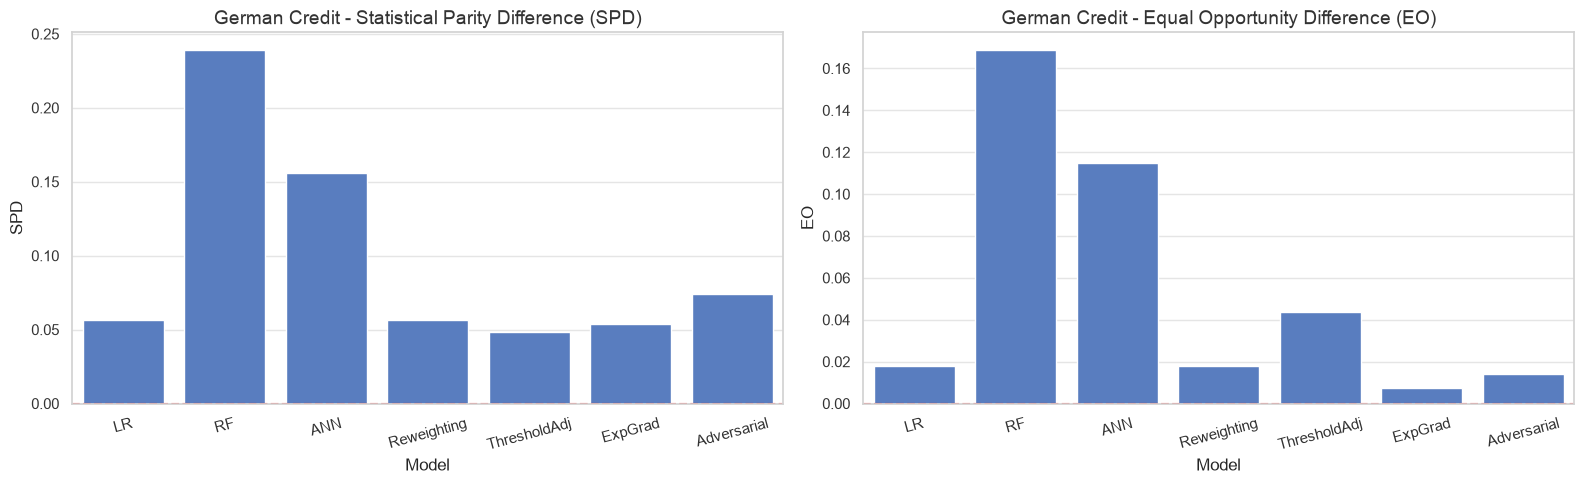

In [6]:
print("\n================ FETCHING GERMAN CREDIT DATASET ================")
url_german = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
cols_german = [f"feature_{i}" for i in range(1, 21)] + ["credit_risk"]
german = pd.read_csv(url_german, sep=' ', names=cols_german, header=None)

# Rename features so SHAP plots generate human-readable axes
german.rename(columns={"feature_13": "age", "feature_1": "checking_account_status"}, inplace=True)

# 1 = Good Credit (Favorable outcome), 2 = Bad Credit (Unfavorable outcome)
german["credit_risk"] = german["credit_risk"].apply(lambda x: 1 if x == 1 else 0)

# Age > 25 is Privileged (1)
prot_german = german["age"].apply(lambda x: 1 if x > 25 else 0)

le_german = LabelEncoder()
for col in german.select_dtypes(include="object").columns:
    german[col] = le_german.fit_transform(german[col])

X_g = german.drop("credit_risk", axis=1)
y_g = german["credit_risk"]

X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g = train_test_split(
    X_g, y_g, prot_german, stratify=prot_german, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_scaled_g = scaler_g.fit_transform(X_train_g)
X_test_scaled_g = scaler_g.transform(X_test_g)

results_german = run_fairness_pipeline(
    X_train_scaled_g, X_test_scaled_g, y_train_g, y_test_g,
    prot_train_g, prot_test_g, X_g.columns, "german", "age"
)
plot_comprehensive_metrics(results_german, "German Credit")


## 5. SHAP Interaction Analysis (Explainability & Indirect Bias)

We compute and plot SHAP interactions to explain how key features interact and potentially introduce indirect bias in Random Forest model predictions.



Computing SHAP Interactions for ADULT...


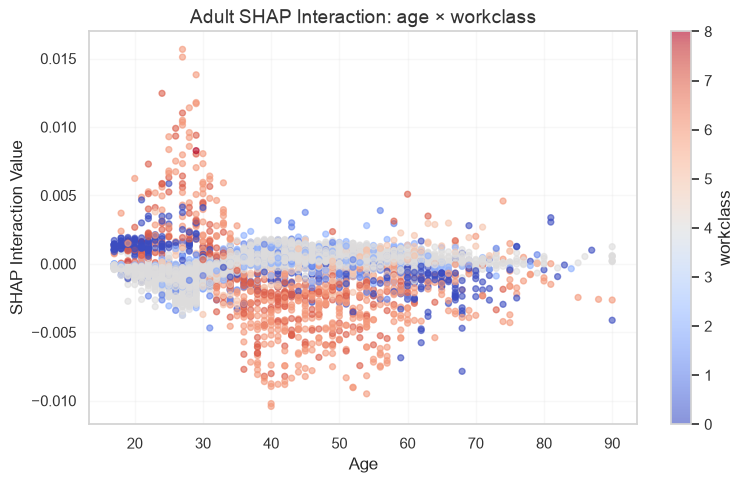


Computing SHAP Interactions for COMPAS...


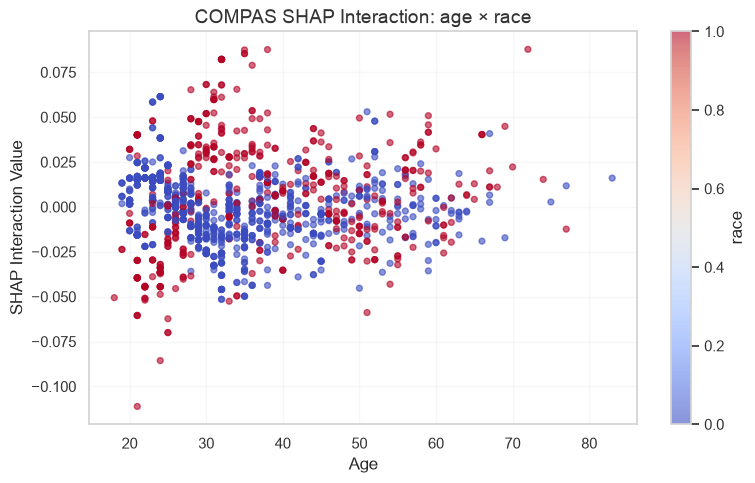


Computing SHAP Interactions for GERMAN_CREDIT...


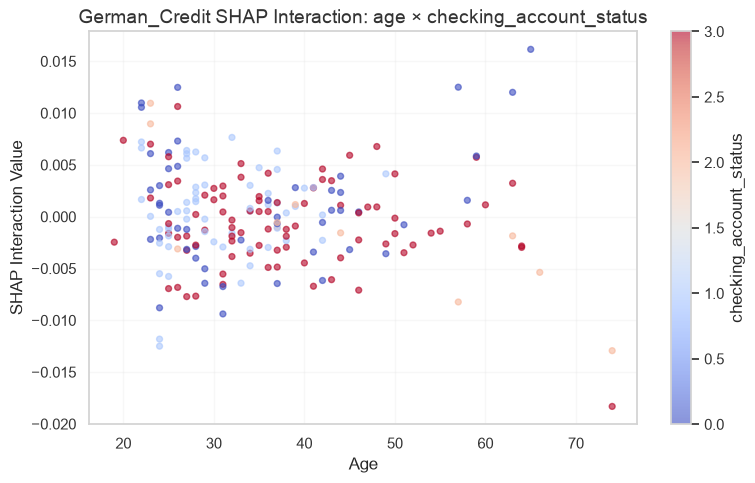

In [7]:
def generate_shap_interactions(X_train, y_train, X_test, feature_names, dataset_name, focus_features):
    """
    Generate SHAP interaction plots.
    """
    print(f"\nComputing SHAP Interactions for {dataset_name.upper()}...")

    rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf_model)
    interaction_values = explainer.shap_interaction_values(X_test)

    if isinstance(interaction_values, list):
        interaction_values = interaction_values[1]
    elif interaction_values.ndim == 4:
        interaction_values = interaction_values[:, :, :, 1]

    idx_0 = feature_names.get_loc(focus_features[0])
    idx_1 = feature_names.get_loc(focus_features[1])

    interaction_effects = interaction_values[:, idx_0, idx_1]

    x_data = X_test.iloc[:, idx_0].to_numpy()
    c_data = X_test.iloc[:, idx_1].to_numpy()
    y_data = np.asarray(interaction_effects).reshape(-1)

    n = min(len(x_data), len(y_data), len(c_data))
    x_data = x_data[:n]; y_data = y_data[:n]; c_data = c_data[:n]

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(x_data, y_data, c=c_data, cmap="coolwarm", alpha=0.6, s=18)
    
    plt.colorbar(scatter, label=focus_features[1])
    plt.xlabel(focus_features[0].replace("_", " ").title())
    plt.ylabel("SHAP Interaction Value")
    plt.title(f"{dataset_name} SHAP Interaction: {focus_features[0]} \u00d7 {focus_features[1]}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower()}_shap_interactions.png", dpi=300)
    plt.show()

# Generate the 3 SHAP plots
adult_feature_names = X_a.columns
generate_shap_interactions(X_train_a, y_train_a, X_test_a, adult_feature_names, "Adult", ["age", "workclass"])

compas_feature_names = X_c.columns
generate_shap_interactions(X_train_c, y_train_c, X_test_c, compas_feature_names, "COMPAS", ["age", "race"])

german_feature_names = X_g.columns
generate_shap_interactions(X_train_g, y_train_g, X_test_g, german_feature_names, "German_Credit", ["age", "checking_account_status"])


## 6. Causal Validation via Feature Ablation

To empirically validate the proxy features identified via SHAP interaction analysis, we perform a feature ablation study. We remove the suspected demographic proxy variables from the training data, retrain the models from scratch, and evaluate the change in accuracy and demographic disparity (Statistical Parity Difference).

If the Statistical Parity Difference decreases significantly while maintaining reasonable accuracy, it empirically confirms that the feature functioned as an active proxy for demographic bias.


In [8]:
def run_ablation_study(X_train, X_test, y_train, y_test, prot_train, prot_test, proxy_col, dataset_name):
    print(f"\n--- Running Ablation Study for {dataset_name.upper()} (Removing Proxy: {proxy_col}) ---")
    
    # Train Random Forest baseline (matching explainability model)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    spd_base, di_base, eo_base, aod_base = fairness_metrics(y_test, y_pred, prot_test)
    acc_base = accuracy_score(y_test, y_pred)
    
    # Train ablated model
    X_train_ablated = X_train.drop(columns=[proxy_col])
    X_test_ablated = X_test.drop(columns=[proxy_col])
    
    rf_ablated = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_ablated.fit(X_train_ablated, y_train)
    y_pred_ablated = rf_ablated.predict(X_test_ablated)
    spd_abl, di_abl, eo_abl, aod_abl = fairness_metrics(y_test, y_pred_ablated, prot_test)
    acc_abl = accuracy_score(y_test, y_pred_ablated)
    
    results = pd.DataFrame({
        "Metric": ["Accuracy", "SPD (Parity)", "DI (Impact)", "EO (Opportunity)"],
        "Original": [acc_base, spd_base, di_base, eo_base],
        "Ablated (No Proxy)": [acc_abl, spd_abl, di_abl, eo_abl],
        "Delta": [acc_abl - acc_base, spd_abl - spd_base, di_abl - di_base, eo_abl - eo_base]
    })
    
    print(results.to_string(index=False))
    
    # Save ablation study results to CSV
    results.to_csv(f"{dataset_name.lower()}_ablation_results.csv", index=False)
    return results

print("\n=== CAUSAL VALIDATION ABLATION STUDIES ===")
# Adult Income Dataset (Proxy: workclass)
run_ablation_study(X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a, "workclass", "Adult")

# COMPAS Recidivism Dataset (Proxy: age)
run_ablation_study(X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c, "age", "COMPAS")

# Statlog German Credit Dataset (Proxy: checking_account_status)
run_ablation_study(X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g, "checking_account_status", "German_Credit")



=== CAUSAL VALIDATION ABLATION STUDIES ===

--- Running Ablation Study for ADULT (Removing Proxy: workclass) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.858283            0.857209 -0.001075
    SPD (Parity)  0.153223            0.155501  0.002278
     DI (Impact)  0.284139            0.285746  0.001607
EO (Opportunity)  0.094962            0.104160  0.009198

--- Running Ablation Study for COMPAS (Removing Proxy: age) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.652807            0.636868 -0.015939
    SPD (Parity)  0.124380            0.184604  0.060225
     DI (Impact)  0.716045            0.509097 -0.206948
EO (Opportunity)  0.152980            0.194950  0.041970

--- Running Ablation Study for GERMAN_CREDIT (Removing Proxy: checking_account_status) ---
          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.810000            0.785000 -0.025000
    SPD (Parity)  0.217024            0.235543  0.018519
     DI (Impact)  0.759193            0.743907 -0.015286
EO (Opportunity)  0.100410            0.191940  0.091530


,Metric,Original,Ablated (No Proxy),Delta
0,Accuracy,0.810000,0.785000,-0.025000
1,SPD (Parity),0.217024,0.235543,0.018519
2,DI (Impact),0.759193,0.743907,-0.015286
3,EO (Opportunity),0.100410,0.191940,0.091530


In [9]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- INTERSECTIONAL FAIRNESS ANALYSIS (Adult Dataset) ---
print("\n--- Preliminary Intersectional Analysis: Race x Gender on Adult Dataset ---")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", 
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", 
           "hours-per-week", "native-country", "income"]
df_adult = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True).dropna()

# We evaluate the intersection of race (White/Non-White) and sex (Male/Female)
df_adult['race_binary'] = df_adult['race'].apply(lambda x: 1 if x == ' White' else 0)
df_adult['sex_binary'] = df_adult['sex'].apply(lambda x: 1 if x == ' Male' else 0)
df_adult['intersectional_group'] = df_adult['race_binary'].astype(str) + "_" + df_adult['sex_binary'].astype(str)
# 1_1: White Male (Privileged)
# 0_0: Non-White Female (Most Unprivileged)

X_inter = df_adult.drop(['income', 'race', 'sex', 'intersectional_group'], axis=1)
X_inter = pd.get_dummies(X_inter, drop_first=True)
y_inter = LabelEncoder().fit_transform(df_adult['income'])
prot_inter = df_adult['intersectional_group']

X_tr_i, X_te_i, y_tr_i, y_te_i, p_tr_i, p_te_i = train_test_split(X_inter, y_inter, prot_inter, test_size=0.3, random_state=42)

rf_inter = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_inter.fit(X_tr_i, y_tr_i)
preds_rf = rf_inter.predict(X_te_i)

print("Evaluating Random Forest on Intersectional Subgroups (Positive Prediction Rates):")
for group in ['1_1', '1_0', '0_1', '0_0']:
    group_mask = (p_te_i == group)
    if np.sum(group_mask) > 0:
        rate = np.mean(preds_rf[group_mask])
        true_rate = np.mean(y_te_i[group_mask])
        print(f"Group {group} -> True Rate: {true_rate:.3f}, Predicted Positive Rate: {rate:.3f}")



--- Preliminary Intersectional Analysis: Race x Gender on Adult Dataset ---


Evaluating Random Forest on Intersectional Subgroups (Positive Prediction Rates):
Group 0_0 -> True Rate: 0.237, Predicted Positive Rate: 0.157
